In [1]:
# ── Cell 1 : Setup & Imports ──────────
import json
import pickle
import pathlib
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

project_root = next(
    p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
    if (p / "pyproject.toml").exists()
)
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src import marginal_comparison as mc

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (15, 4)
print("Imports successful!")

Imports successful!


In [2]:
# ── Cell 2 : Locate Sibling Sampler Runs ──────────
# This notebook sits in a <chains>/<k>_comp/ folder and compares the NUTS, HMC and
# bayesm runs that live beside it: <sampler>/<run>/results/posterior_raw.pkl.

def _resolve_dir():
    nb = globals().get("__vsc_ipynb_file__")
    return pathlib.Path(nb).resolve().parent if nb else pathlib.Path.cwd()

XCOMP_DIR = _resolve_dir()
hits = sorted(XCOMP_DIR.glob("*/*/results/posterior_raw.pkl"))
if not hits:
    raise FileNotFoundError(
        f"No <sampler>/<run>/results/posterior_raw.pkl under:\n  {XCOMP_DIR}\n"
        f"This notebook must sit in a <chains>/<k>_comp/ folder. In VS Code set\n"
        f'  "jupyter.notebookFileRoot": "${{fileDirname}}"  and restart the kernel.'
    )

runs = {}
for h in hits:
    sampler = h.parents[2].name          # NUTS / HMC / bayesm
    runs.setdefault(sampler, h.parent)   # first run's results dir per sampler

meta = json.load(open(next(iter(runs.values())) / "meta.json"))
SCENARIO = meta["scenario"]
K_MODEL  = int(meta["k_model"])
K_TRUE   = int(meta["k_true"])
CHAINS   = int(meta["chains"])

print(f"x_comp folder : {XCOMP_DIR}")
print(f"scenario={SCENARIO}  K_MODEL={K_MODEL}  K_TRUE={K_TRUE}")
print(f"samplers found: {list(runs)}")

models = [mc.load_sampler(rd, name) for name, rd in runs.items()]
for m in models:
    print(f"  {m['name']:<8} mu {m['mu'].shape}")

x_comp folder : C:\Users\ThinkPad\Desktop\Repositories\HierarchicalBayesianMultinomialLogit\hbmnl_mixture_experiments\1_chain\5_comp
scenario=5comp_equal  K_MODEL=5  K_TRUE=5
samplers found: ['bayesm', 'HMC', 'NUTS', 'replication']


  bayesm   mu (1, 10000, 5, 4)
  HMC      mu (1, 10000, 5, 4)
  NUTS     mu (1, 10000, 5, 4)
  replication mu (1, 10000, 5, 4)


In [3]:
# ── Cell 3 : Ground Truth & Grids (Full + Chebyshev) ──────────
# Two grids per parameter, used by all cells below; the True DGP only enters the
# envelopes and stays an overlay in the plots.
#   "Full"      - min/max envelope over every component of every sampler + True
#                 DGP; nothing excluded, can be very wide.
#   "Chebyshev" - each model's aggregate mixture mean +/- 5*std; covers >=96% of
#                 its marginal mass for any distribution.
raw = json.load(open(project_root / "data" / "simulated" / "mixture" / f"{SCENARIO}.json"))
P = int(raw["n_params"])
param_names = raw.get("param_names") or [f"Param_{i}" for i in range(P)]
true_model = mc.true_dgp_model(raw)

GRIDS = {
    "Full":                  mc.build_grids_full(models, true_model, n_grid=1000, n_sigma=6),
    "Chebyshev (k=5, >=96%)": mc.build_grids_chebyshev(models, true_model, n_grid=1000, k=5.0),
}
for label, grids in GRIDS.items():
    print(f"Grid extents [{label}]:")
    for j, pj in enumerate(param_names):
        print(f"  {pj:<10} [{grids[j][0]:+.2f}, {grids[j][-1]:+.2f}]")

Grid extents [Full]:
  Alt1       [-260.48, +256.10]
  Alt2       [-346.03, +307.15]
  Alt3       [-122.35, +101.56]
  Price      [-119.54, +117.70]
Grid extents [Chebyshev (k=5, >=96%)]:
  Alt1       [-8.56, +13.34]
  Alt2       [-13.47, +16.12]
  Alt3       [-15.80, +17.10]
  Price      [-21.98, +19.67]


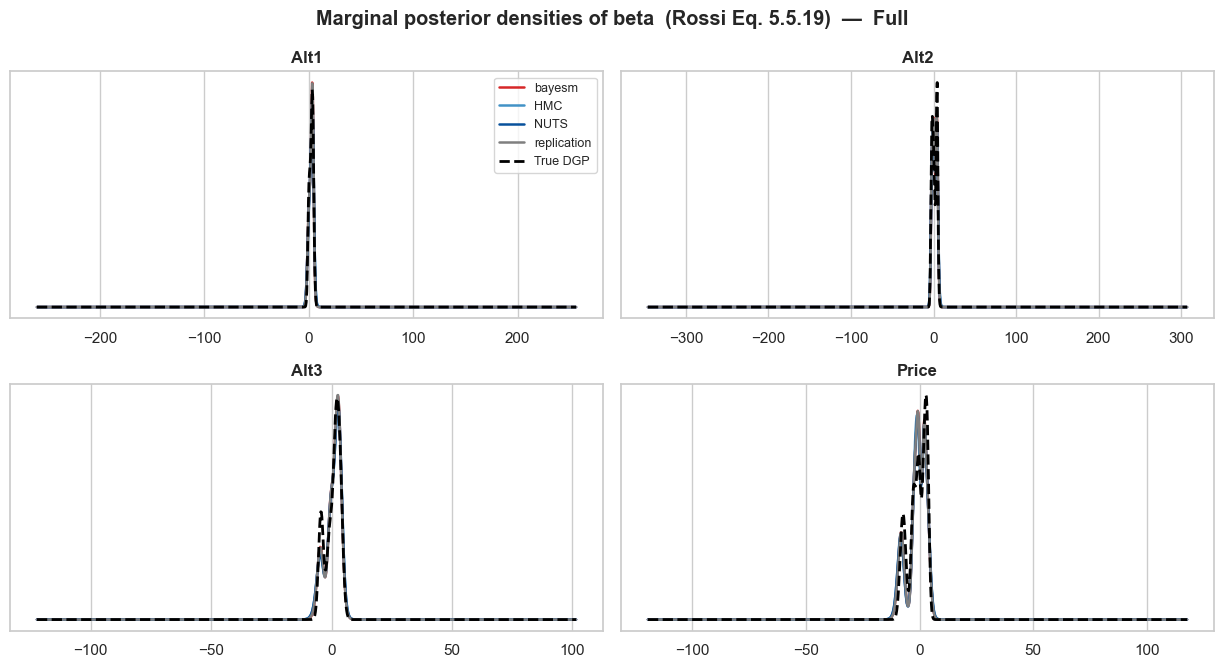

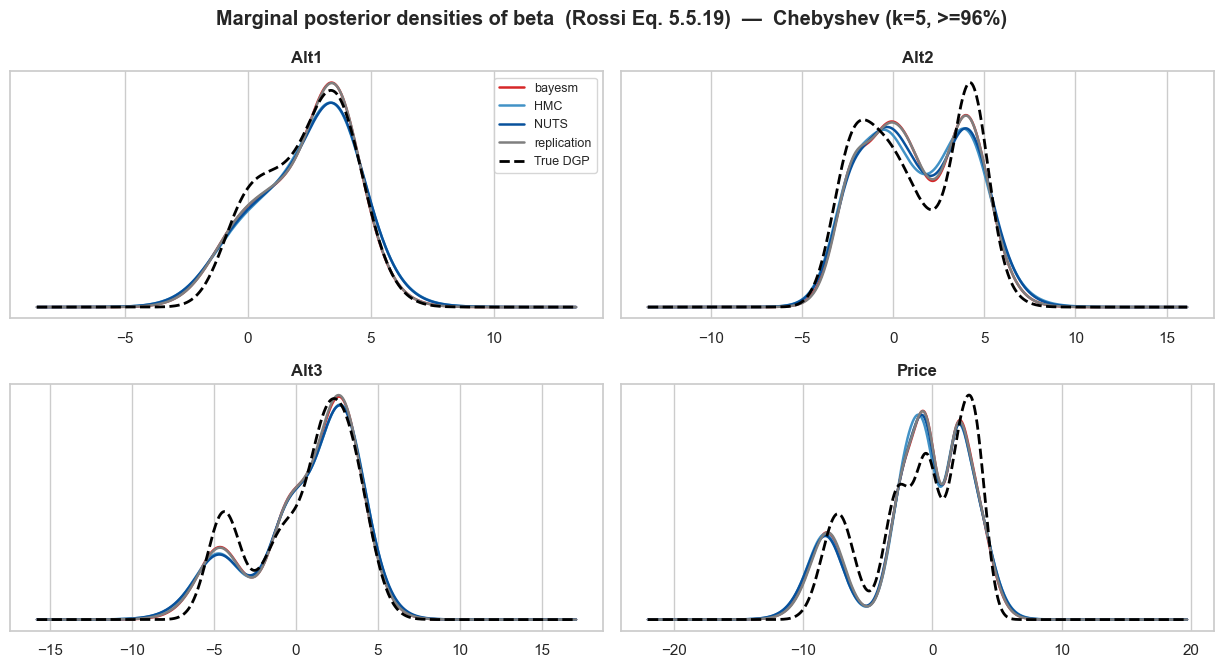

In [4]:
# ── Cell 4 : Marginal Densities (Rossi Eq. 5.5.19) - Full vs Chebyshev ──────────
# One figure per grid pass; True DGP dashed black, bayesm red, Liesel samplers in
# blues. Densities are cached in DENS/DENS_TRUE and reused by Cell 5.
colors = {"NUTS": "#08519c", "HMC": "#4292c6", "bayesm": "#d62728"}
TRUE_COLOR = "#000000"
ncols = min(P, 2)
nrows = int(np.ceil(P / ncols))

DENS, DENS_TRUE = {}, {}
for label, grids in GRIDS.items():
    dens      = {m["name"]: mc.marginal_density(m, grids) for m in models}
    dens_true = mc.marginal_density(true_model, grids)
    DENS[label], DENS_TRUE[label] = dens, dens_true

    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 6.2, nrows * 3.4), squeeze=False)
    ax = axes.ravel()
    for j, pj in enumerate(param_names):
        for name, d in dens.items():
            ax[j].plot(grids[j], d[j], lw=1.8, label=name, color=colors.get(name, "#7f7f7f"))
        ax[j].plot(grids[j], dens_true[j], lw=2.0, ls="--", color=TRUE_COLOR, label="True DGP")
        ax[j].set_title(pj, fontweight="bold")
        ax[j].set_yticks([])
    for j in range(P, len(ax)):
        ax[j].set_visible(False)
    ax[0].legend(fontsize=9)
    fig.suptitle(f"Marginal posterior densities of beta  (Rossi Eq. 5.5.19)  —  {label}",
                 fontweight="bold")
    fig.tight_layout()
    plt.show()

In [5]:
# ── Cell 5 : Density Distances vs True DGP - Full vs Chebyshev ──────────
# Each sampler vs the True DGP only (never sampler-vs-sampler): Hellinger
# (primary), KL(model||true), JSD, TVD, Wasserstein-1. Reuses DENS/DENS_TRUE.
for label, grids in GRIDS.items():
    print(f"--- {label} ---")
    display(mc.distance_table(models, true_model, grids, param_names,
                               dens=DENS[label], dens_true=DENS_TRUE[label]))

--- Full ---


C:\Users\ThinkPad\Desktop\Repositories\HierarchicalBayesianMultinomialLogit\src\marginal_comparison.py:283: RuntimeWarning: overflow encountered in divide
  term = np.where((a > 0) & (b > 0), a * np.log(a / np.where(b > 0, b, 1.0)), 0.0)


Hellinger       KL      JSD      TVD  Wasserstein1
sampler     param                                                    
bayesm      Alt1     0.06873  0.02628  0.00445  0.04166       0.10552
            Alt2     0.07024  0.02043  0.00491  0.08544       0.23726
            Alt3     0.08890  0.04656  0.00737  0.06387       0.19789
            Price    0.14099  0.09846  0.01902  0.13932       0.38300
HMC         Alt1     0.09485      inf  0.00828  0.06200       0.19573
            Alt2     0.08844      inf  0.00748  0.09000       0.24998
            Alt3     0.11147      inf  0.01129  0.08030       0.26532
            Price    0.15996      inf  0.02412  0.15065       0.41530
NUTS        Alt1     0.09245      inf  0.00792  0.06209       0.19093
            Alt2     0.08397      inf  0.00690  0.09253       0.24885
            Alt3     0.11268      inf  0.01155  0.07955       0.26831
            Price    0.15606      inf  0.02296  0.14703       0.40887
replication Alt1     0.06740  0.02505  0.00428  0.04060       0.10498
            Alt2     0.07167  0.02120  0.00511  0.08649       0.24507
            Alt3     0.09140  0.05189  0.00773  0.06319       0.20335
            Price    0.13864  0.09436  0.01843  0.13873       0.37830

--- Chebyshev (k=5, >=96%) ---


Hellinger       KL      JSD      TVD  Wasserstein1
sampler     param                                                    
bayesm      Alt1     0.06873  0.02627  0.00445  0.04176       0.10487
            Alt2     0.07024  0.02043  0.00491  0.08533       0.23575
            Alt3     0.08890  0.04655  0.00737  0.06379       0.19772
            Price    0.14099  0.09845  0.01902  0.13913       0.38285
HMC         Alt1     0.09378  0.05498  0.00814  0.06198       0.18899
            Alt2     0.08705  0.03993  0.00731  0.08880       0.23704
            Alt3     0.11142  0.09025  0.01128  0.08035       0.26480
            Price    0.15993  0.14179  0.02412  0.15085       0.41479
NUTS        Alt1     0.09225  0.05205  0.00789  0.06248       0.18946
            Alt2     0.08392  0.03257  0.00689  0.09173       0.24657
            Alt3     0.11266  0.08804  0.01155  0.07964       0.26788
            Price    0.15606  0.13127  0.02296  0.14730       0.40811
replication Alt1     0.06740  0.02505  0.00428  0.04089       0.10439
            Alt2     0.07167  0.02120  0.00511  0.08624       0.24400
            Alt3     0.09140  0.05188  0.00773  0.06311       0.20318
            Price    0.13864  0.09436  0.01843  0.13862       0.37798

In [6]:
# ── Cell 6 : Mixture Moments (Rossi Eq. 5.5.2) & Weights ──────────
# Grid-independent (analytic in the draws); runs once.
allm = models + [true_model]
mean_tbl = pd.DataFrame({m["name"]: mc.mixture_moments(m)[0] for m in allm}, index=param_names)
var_tbl  = pd.DataFrame({m["name"]: np.diag(mc.mixture_moments(m)[1]) for m in allm}, index=param_names)
print("E[theta]  (overall mixture mean):")
display(mean_tbl.round(3))
print("diag Var[theta]  (overall mixture variance):")
display(var_tbl.round(3))

E[theta]  (overall mixture mean):


,bayesm,HMC,NUTS,replication,True DGP
Alt1,2.342,2.391,2.394,2.344,2.388
Alt2,1.315,1.329,1.344,1.324,1.142
Alt3,0.634,0.646,0.653,0.633,0.560
Price,-1.125,-1.153,-1.146,-1.115,-1.000


diag Var[theta]  (overall mixture variance):


,bayesm,HMC,NUTS,replication,True DGP
Alt1,4.155,4.796,4.658000,4.146,3.603
Alt2,7.810,8.755,8.375000,7.766,8.496
Alt3,10.173,10.818,10.821000,10.191,9.511
Price,16.564,17.344,17.214001,16.458,15.138


In [7]:
# ── Cell 7 : Convergence of the Marginals - Goose-identical functional diagnostics ──────────
# az.rhat (rank) / az.ess (bulk, tail) - the exact calls in Goose's summary() -
# on grid-free functionals of each per-draw marginal: mean, sd, q05/q50/q95.
# ESS/s divides by the fit's total wall-clock (meta.json duration_s, incl.
# warmup). Read ESS only where R-hat ~ 1. Alternatives: mc.curve_diagnostics,
# mc.density_series_diagnostics.
if CHAINS == 1:
    print("NOTE: single chain -> split-chain diagnostics; WITHIN-chain checks only.\n")

for m in models:
    rt = m.get("duration_s")
    print(f"--- {m['name']}" + (f"  (fit wall-clock: {rt:,.0f}s)" if rt else "") + " ---")
    display(mc.functional_diagnostics(m, param_names).round(3))

NOTE: single chain -> split-chain diagnostics; WITHIN-chain checks only.

--- bayesm  (fit wall-clock: 223s) ---


Rhat  ESS_bulk  ESS_tail  ESS_bulk/s  ESS_tail/s
param functional                                                   
Alt1  mean        1.004   917.446  2957.329       4.109      13.244
      sd          1.005   736.198  2041.455       3.297       9.142
      q05         1.000  2376.032  4623.194      10.641      20.704
      q50         1.002   717.557  3064.118       3.213      13.722
      q95         1.008   413.092  1162.001       1.850       5.204
Alt2  mean        1.001  1374.923  4385.553       6.157      19.640
      sd          1.002   496.148  1609.322       2.222       7.207
      q05         1.008   280.833  1105.778       1.258       4.952
      q50         1.002  1400.135  3957.896       6.270      17.725
      q95         1.001   484.880  1386.020       2.171       6.207
Alt3  mean        1.001  1190.664  4365.294       5.332      19.549
      sd          1.004   304.356   952.253       1.363       4.264
      q05         1.005   257.703   584.564       1.154       2.618
      q50         1.003  2138.314  4841.468       9.576      21.681
      q95         1.005   563.058  1435.418       2.522       6.428
Price mean        1.005  1010.123  4310.356       4.524      19.303
      sd          1.017   220.491   702.783       0.987       3.147
      q05         1.037   105.005   202.910       0.470       0.909
      q50         1.000  8404.051  8652.017      37.636      38.746
      q95         1.003   417.143  1147.591       1.868       5.139

--- HMC  (fit wall-clock: 286s) ---


Rhat  ESS_bulk  ESS_tail  ESS_bulk/s  ESS_tail/s
param functional                                                   
Alt1  mean        1.006   408.117  1225.965       1.426       4.284
      sd          1.038    53.303    47.398       0.186       0.166
      q05         1.002  1451.147  3708.368       5.070      12.957
      q50         1.003   510.817  1821.358       1.785       6.364
      q95         1.010   234.669   610.121       0.820       2.132
Alt2  mean        1.005   341.274  1179.516       1.192       4.121
      sd          1.073    23.078    30.261       0.081       0.106
      q05         1.011   289.212   853.259       1.011       2.981
      q50         1.008   410.359  1471.608       1.434       5.142
      q95         1.002   344.738   980.889       1.205       3.427
Alt3  mean        1.004   312.029  1045.218       1.090       3.652
      sd          1.003   245.472   581.247       0.858       2.031
      q05         1.004   185.352   450.654       0.648       1.575
      q50         1.002   784.552  2510.857       2.741       8.773
      q95         1.016   224.435   503.549       0.784       1.759
Price mean        1.026   155.425   362.640       0.543       1.267
      sd          1.010   228.974   473.980       0.800       1.656
      q05         1.007   180.445   307.166       0.630       1.073
      q50         1.033   167.747  1015.965       0.586       3.550
      q95         1.021   202.529   415.806       0.708       1.453

--- NUTS  (fit wall-clock: 657s) ---


Rhat  ESS_bulk  ESS_tail  ESS_bulk/s  ESS_tail/s
param functional                                                   
Alt1  mean        1.001  1516.500  4137.637       2.307       6.295
      sd          1.003   658.356   616.077       1.002       0.937
      q05         1.001  2788.253  4308.790       4.242       6.555
      q50         1.001  1371.238  3381.562       2.086       5.145
      q95         1.001   638.768   929.952       0.972       1.415
Alt2  mean        1.001  2888.064  5614.709       4.394       8.542
      sd          1.004   801.173  2261.271       1.219       3.440
      q05         1.001  1037.148  2531.386       1.578       3.851
      q50         1.001  2550.146  5923.098       3.880       9.011
      q95         1.001   832.944  1699.184       1.267       2.585
Alt3  mean        1.001  1777.364  4312.322       2.704       6.561
      sd          1.004   831.119  1701.549       1.264       2.589
      q05         1.006   662.179  1266.130       1.007       1.926
      q50         1.001  3699.067  6267.674       5.628       9.535
      q95         1.004   844.665  1499.609       1.285       2.281
Price mean        1.000  3253.300  5953.495       4.949       9.058
      sd          1.001   953.052  2027.168       1.450       3.084
      q05         1.003   635.657  1606.241       0.967       2.444
      q50         1.001  7329.851  8472.058      11.151      12.889
      q95         1.002  1137.379  2530.912       1.730       3.850

--- replication  (fit wall-clock: 187s) ---


Rhat  ESS_bulk  ESS_tail  ESS_bulk/s  ESS_tail/s
param functional                                                   
Alt1  mean        1.000   778.547  2790.244       4.166      14.929
      sd          1.001   682.162  1933.033       3.650      10.343
      q05         1.001  1926.679  4504.842      10.309      24.103
      q50         1.000   600.723  2165.367       3.214      11.586
      q95         1.003   433.640   996.824       2.320       5.333
Alt2  mean        1.001  1891.187  5657.672      10.119      30.271
      sd          1.009   439.378  1425.281       2.351       7.626
      q05         1.002   449.095   981.090       2.403       5.249
      q50         1.001  1426.409  4267.083       7.632      22.831
      q95         1.016   425.804  1516.338       2.278       8.113
Alt3  mean        1.001  1110.620  3460.502       5.942      18.515
      sd          1.001   362.051  1040.286       1.937       5.566
      q05         1.004   276.918   704.802       1.482       3.771
      q50         1.001  1774.240  5344.485       9.493      28.595
      q95         1.010   424.248  1270.247       2.270       6.796
Price mean        1.000  1404.984  4234.415       7.517      22.656
      sd          1.002   196.442   419.620       1.051       2.245
      q05         1.006   122.635   206.701       0.656       1.106
      q50         1.000  7604.025  8783.922      40.685      46.998
      q95         1.003   403.531  1339.992       2.159       7.170

In [8]:
# ── Cell 8 : Notes ──────────
print("Notes:")
print(" - All quantities are label-invariant: relabeling/ECR would not change them.")
print(" - Grids: 'Full' = unbounded envelope over every component + True DGP;")
print("   'Chebyshev (k=5)' = each model's mixture mean +/- 5*std (>=96% mass).")
print(" - Cell 7: Goose-identical arviz diagnostics (rank split-R-hat, bulk/tail")
print("   ESS) on grid-free functionals of each per-draw marginal.")
print(" - 1-chain runs: chains split into halves - a within-chain check only.")
print("   bayesm's seed-based chains are not over-dispersed (weaker R-hat test).")

Notes:
 - All quantities are label-invariant: relabeling/ECR would not change them.
 - Grids: 'Full' = unbounded envelope over every component + True DGP;
   'Chebyshev (k=5)' = each model's mixture mean +/- 5*std (>=96% mass).
 - Cell 7: Goose-identical arviz diagnostics (rank split-R-hat, bulk/tail
   ESS) on grid-free functionals of each per-draw marginal.
 - 1-chain runs: chains split into halves - a within-chain check only.
   bayesm's seed-based chains are not over-dispersed (weaker R-hat test).
